In [1]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt

from mcp_boltzmann import plasma as plas

In [2]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

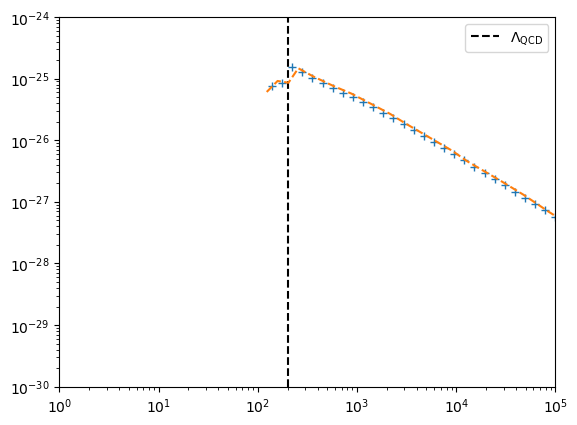

In [16]:
T_range = np.geomspace(1, 1e5)
# T_range = np.array(shelton_f7_plasmon[0])*GeV_to_MeV
L_QCD = 200
GeV_to_MeV = 1e3

shelton_f7_plasmon = load_csv('../input/fig/2206.13530_fig7_left_plasmon.csv')

plasmon_rate_res = plas.C_plasmon(T_range, 0, 10, 1e-9)

plt.plot(T_range, plasmon_rate_res/T_range**6, linestyle='none', marker='+')
plt.axvline(L_QCD, linestyle='dashed', color='black', label=r'$\Lambda_{\rm QCD}$')
plt.plot
plt.plot(np.array(shelton_f7_plasmon[0])*GeV_to_MeV, shelton_f7_plasmon[1], linestyle='dashed')
plt.yscale('log')
plt.xscale('log')
plt.xlim(1, 1e5)
plt.ylim(1e-30, 1e-24)
plt.legend()


In [7]:
from scipy.interpolate import interp1d
dunc_I = interp1d(T_range, plasmon_rate_res/T_range**6)
shel_I = interp1d(np.array(shelton_f7_plasmon[0])*GeV_to_MeV, shelton_f7_plasmon[1], bounds_error=False, fill_value=0)

In [10]:
R = (shel_I(T_range)/dunc_I(T_range))

/var/folders/9z/c613c55s37gc7sthc_2397hc0000gn/T/ipykernel_48785/1463472524.py:1: RuntimeWarning: invalid value encountered in divide
  R = (shel_I(T_range)/dunc_I(T_range))


In [14]:
R[np.where(~np.isnan(R))].mean()

1.0956795316738064